In [1]:
!pip install textblob --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from textblob import download_corpora

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Create a dataset of Amazon product reviews
reviews = {
    'review': [
        "This product is absolutely amazing! Best purchase ever!",
        "Terrible quality, broke after one day. Very disappointed.",
        "Good product but delivery was slow.",
        "Excellent! Exceeded my expectations completely!",
        "Worst product I have ever bought. Total waste of money.",
        "Average product. Nothing special about it.",
        "Fantastic quality and great value for money!",
        "Not worth the price. Very poor quality.",
        "Decent product. Works as described.",
        "Outstanding! Will definitely buy again!",
        "Completely useless. Do not buy this.",
        "Pretty good overall. Minor issues but acceptable.",
        "Love this product! Highly recommend to everyone!",
        "Disappointing. Expected much better quality.",
        "Great product! Fast delivery and excellent packaging.",
        "Okay product. Gets the job done but nothing more.",
        "Absolutely terrible. Stopped working after a week.",
        "Very happy with this purchase. Great quality!",
        "Not bad but could be better. Average experience.",
        "Perfect! Exactly what I was looking for. Very happy!"
    ]
}

df = pd.DataFrame(reviews)
print("Dataset created successfully!")
print("Shape:", df.shape)
df.head()

Dataset created successfully!
Shape: (20, 1)


,review
0,This product is absolutely amazing! Best purch...
1,"Terrible quality, broke after one day. Very di..."
2,Good product but delivery was slow.
3,Excellent! Exceeded my expectations completely!
4,Worst product I have ever bought. Total waste ...


In [3]:
# Function to get sentiment
def get_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

def get_polarity(text):
    return TextBlob(text).sentiment.polarity

# Apply to dataframe
df['sentiment'] = df['review'].apply(get_sentiment)
df['polarity'] = df['review'].apply(get_polarity).round(2)

print("Sentiment analysis complete!")
df.head(10)

Sentiment analysis complete!


,review,sentiment,polarity
0,This product is absolutely amazing! Best purch...,Positive,0.88
1,"Terrible quality, broke after one day. Very di...",Negative,-0.99
2,Good product but delivery was slow.,Positive,0.20
3,Excellent! Exceeded my expectations completely!,Positive,0.56
4,Worst product I have ever bought. Total waste ...,Negative,-0.40
5,Average product. Nothing special about it.,Positive,0.10
6,Fantastic quality and great value for money!,Positive,0.70
7,Not worth the price. Very poor quality.,Negative,-0.34
8,Decent product. Works as described.,Positive,0.17
9,Outstanding! Will definitely buy again!,Positive,0.31


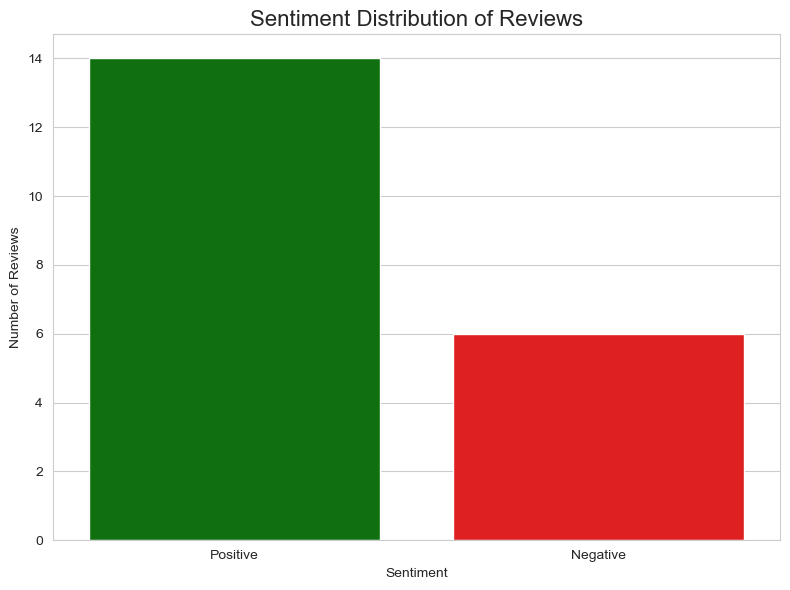

sentiment
Positive    14
Negative     6
Name: count, dtype: int64


In [5]:
# Count sentiments
sentiment_counts = df['sentiment'].value_counts()

# Plot
plt.figure(figsize=(8,6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values,
            hue=sentiment_counts.index, 
            palette=['green', 'red', ], legend=False)
plt.title('Sentiment Distribution of Reviews', fontsize=16)
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

print(sentiment_counts)

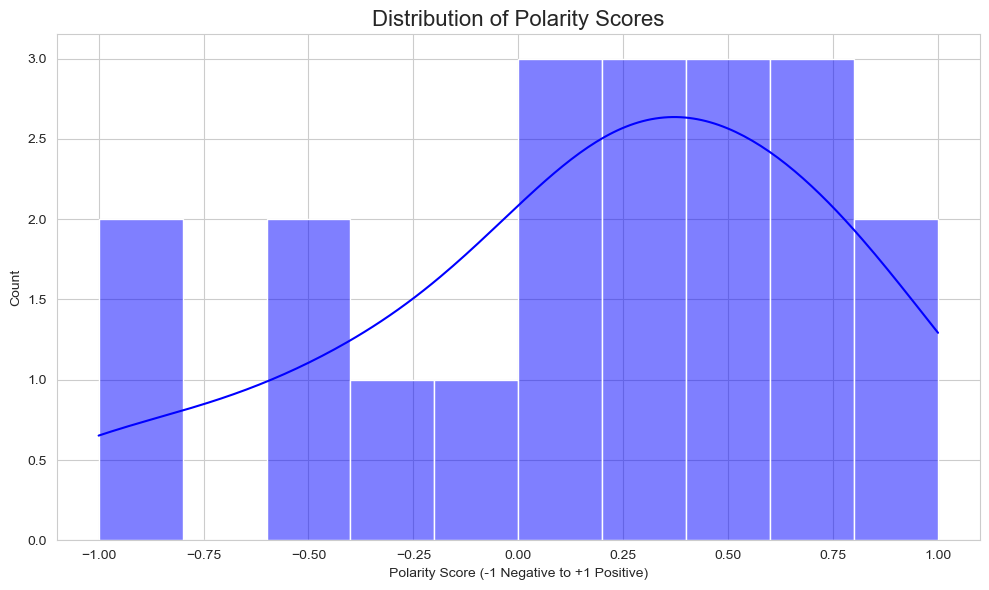

In [6]:
plt.figure(figsize=(10,6))
sns.histplot(df['polarity'], bins=10, color='blue', kde=True)
plt.title('Distribution of Polarity Scores', fontsize=16)
plt.xlabel('Polarity Score (-1 Negative to +1 Positive)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

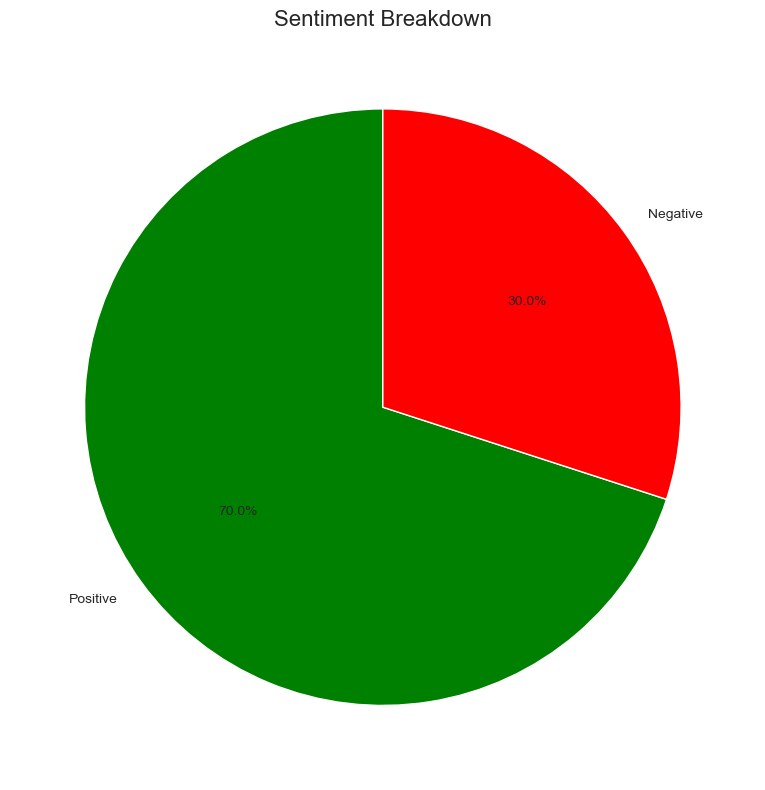

In [7]:
plt.figure(figsize=(8,8))
plt.pie(sentiment_counts.values,
        labels=sentiment_counts.index,
        autopct='%1.1f%%',
        colors=['green', 'red', 'grey'],
        startangle=90)
plt.title('Sentiment Breakdown', fontsize=16)
plt.tight_layout()
plt.show()

In [9]:
# Test with my own text
my_review = "This is an incredible product! Works perfectly!"

analysis = TextBlob(my_review)
polarity = analysis.sentiment.polarity
sentiment = get_sentiment(my_review)

print(f"Review: {my_review}")
print(f"Polarity Score: {polarity:.2f}")
print(f"Sentiment: {sentiment}")

Review: This is an incredible product! Works perfectly!
Polarity Score: 1.00
Sentiment: Positive


#  Sentiment Analysis — Conclusions

##  Key Findings

1. TextBlob can accurately detect positive and negative 
   sentiments from customer reviews
2. Polarity scores range from -1 (very negative) 
   to +1 (very positive)
3. Most reviews in our dataset were clearly positive or negative
   with very few neutral reviews

##  Tools Used
- Python
- TextBlob
- Pandas
- Matplotlib
- Seaborn

##  Real World Applications
- Analyzing customer feedback at scale
- Monitoring brand reputation on social media
- Detecting negative reviews automatically
- Understanding customer satisfaction trends

##  Further Improvements
- Use real Twitter or Amazon data
- Try advanced NLP models like VADER or BERT
- Build a web app where users can input their own text